### Dataset download ###

In [1]:
import sys
from dotenv import load_dotenv
import os
import numpy as np
import pandas as pd
import glob
import tarfile
from pathlib import Path
from matplotlib import pyplot as plt

# Appearance of the Notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Import this module with autoreload
%load_ext autoreload
%autoreload 2

import computervision as cv
from computervision.fileutils import FileOP
from computervision.imageproc import ImageData, is_image
from computervision.imageproc import plot_boxes, enclosing_box, xyxy2xywh, clipxywh, crop_image

# Print version info
print(f'Package version: {cv.__version__}')
print(f'Authors:         {cv.__authors__}')
print(f'Python version:  {sys.version}')

Package version: 0.0.1
Authors:         The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.13 (main, Jun 24 2026, 02:08:01) [GCC 14.2.0]


Full data set: https://universe.roboflow.com/shauns-flow/dental-aq0l2

pre-processed: https://dsets.s3.us-east-1.amazonaws.com/classification_datasets/dataset_dental_roboflow.tar.gz

In [2]:
# Load environmental variables
load_dotenv()
data_root = os.environ.get('DATA_DIR')
if data_root is None:
    print('Edit the "env"file and copy it to the root of the repository.') 
    raise FileNotFoundError('No .env file found. The data directory was not set.')
    
# Directory to store the data
dataset_name = 'classification'
data_dir = os.path.join(data_root, dataset_name)
Path(data_dir).mkdir(parents=True, exist_ok=True)
print(f'Using "{data_dir}" for data download.')

# Directory to save some example images
example_dir = os.path.join(data_dir, 'examples')
Path(example_dir).mkdir(parents=True, exist_ok=True)

Using "/app/data/classification" for data download.


### Download the data set ###

In [3]:
url = os.environ.get('CL_URL')
print(f'Link for manual download: \n {url}')
file = FileOP().download_from_url(url=url, download_dir=data_dir)
if file is not None and os.path.exists(file):
    try:
        with tarfile.open(file) as tar:
            tar.extractall(path=data_dir, filter='data')
    except Exception as e:
        logger.error(f'Failed to extract tar file: {e}')
image_dir_name = os.path.basename(url).split('.')[0]
image_dir = os.path.join(data_dir, image_dir_name)
print(image_dir)

# Verify the image data on disk
file_list = glob.glob(os.path.join(image_dir, '*.jpg'))
print(len(file_list))

Link for manual download: 
 https://dsets.s3.us-east-1.amazonaws.com/classification_datasets/dataset_dental_roboflow.tar.gz


dataset_dental_roboflow.tar.gz: 26.4MB [00:00, 28.8MB/s]                            


Extracting from .gz archive.
/app/data/classification/dataset_dental_roboflow
995


In [4]:
# Open the annotation file (in the image directory after extraction)
annotations_file_name = 'annotations.parquet'
annotations_file = os.path.join(image_dir, annotations_file_name)
df = pd.read_parquet(annotations_file)
display(df.head(2))
print(df.shape)

file_col = 'multi_file'
bbox_col= 'bbox'
disease_col = 'disease'
pos_col = 'pos'
label_col = 'label'

# Chceck the images
file_list = [os.path.join(image_dir, file_name) for file_name in df[file_col].unique()]
checked = [is_image(file) for file in file_list]
assert len(file_list) == sum(checked), f'WARNING: Could not open all {len(file_list)} images at: {image_dir}'
print(f'Image directory:        {image_dir}')
print(f'Total number of images: {len(file_list)}')
print(f'Annotations:            {df.shape[0]}')

,id,license,file_name,height,width,date_captured,file_name_hash,dset,multi_file,bbox,category,disease,pos,box_id
0,0,1,pbws-super-set-1-completed__PBWs_Super_Set_2-0...,480,640,2024-09-17T23:44:33+00:00,40762886f4,train,40762886f4.jpg,"[381.0, 242.0, 481.474, 279.948]",composite,composite,NaN,40762886f4_0
1,0,1,pbws-super-set-1-completed__PBWs_Super_Set_2-0...,480,640,2024-09-17T23:44:33+00:00,40762886f4,train,40762886f4.jpg,"[8.0, 0.0, 130.293, 176.736]",tooth 23,teeth,11.0,40762886f4_1


(12559, 14)
Image directory:        /app/data/classification/dataset_dental_roboflow
Total number of images: 993
Annotations:            12559


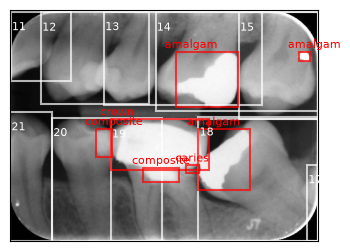

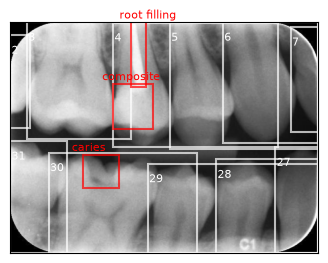

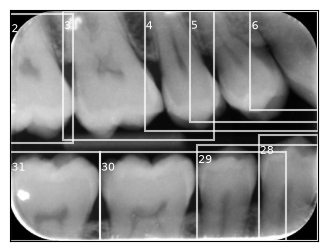

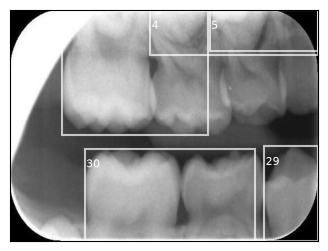

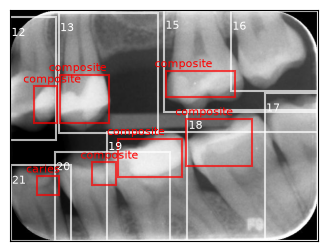

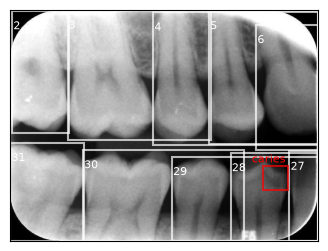

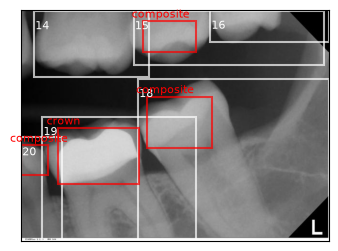

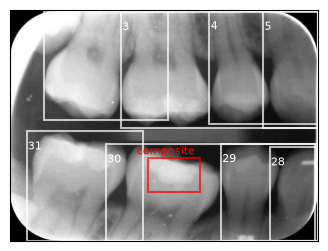

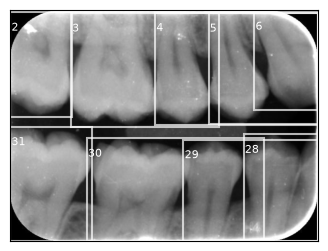

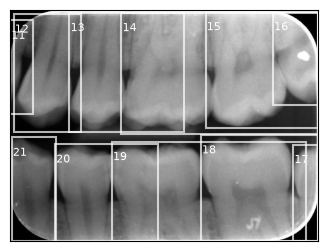

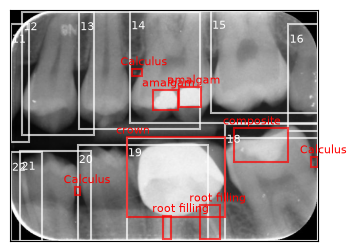

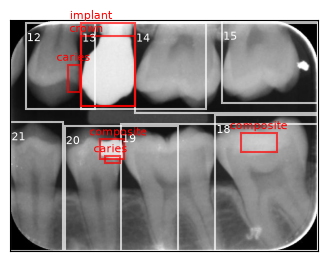

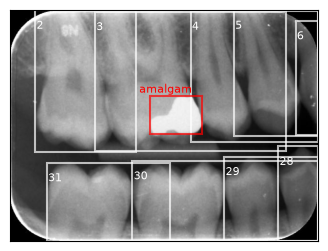

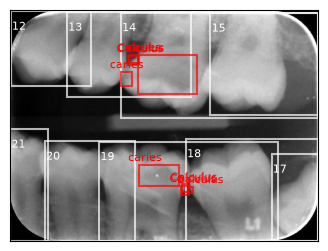

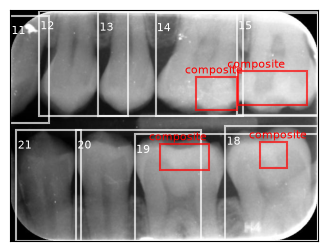

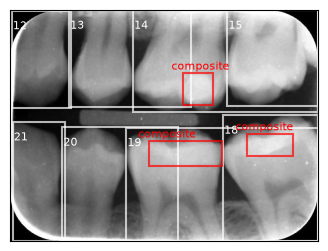

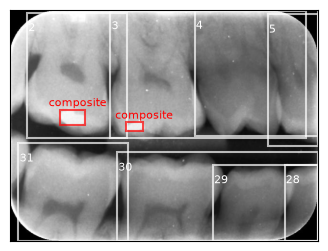

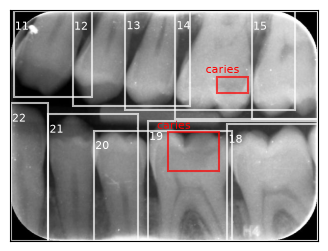

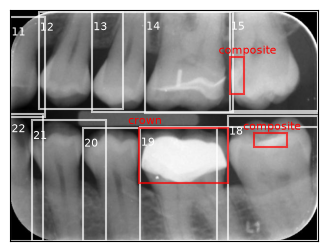

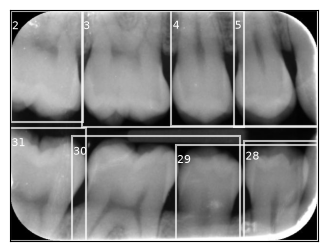

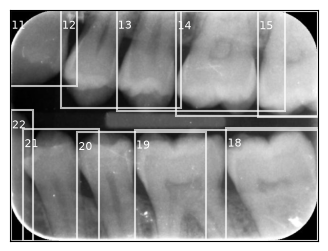

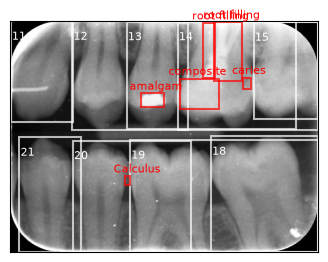

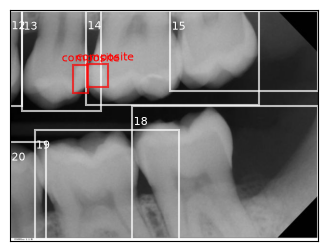

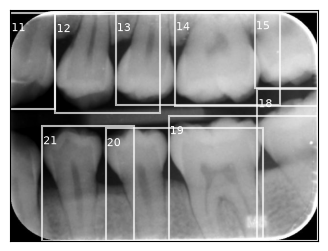

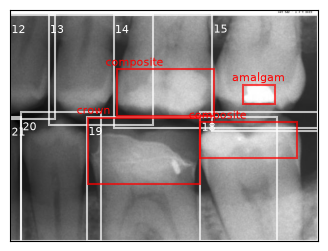

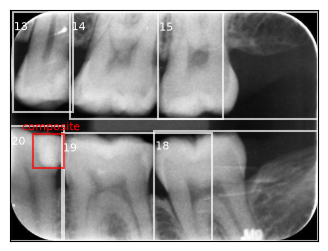

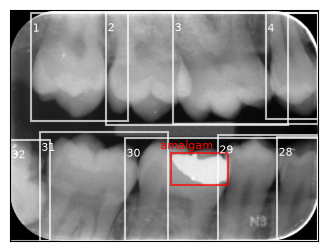

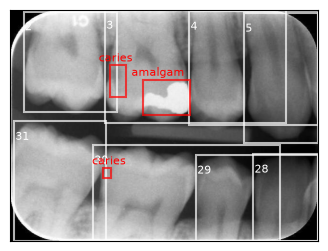

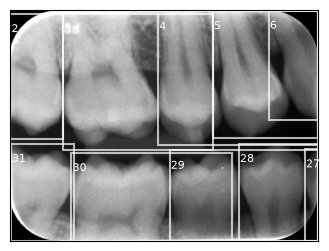

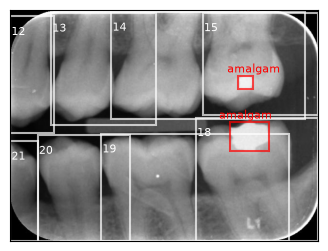

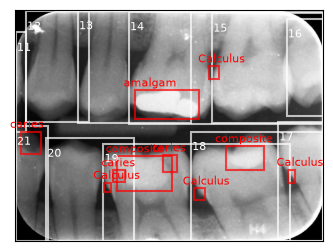

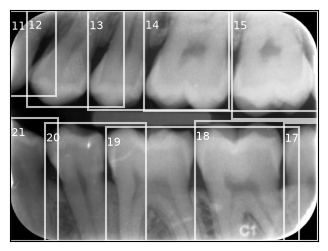

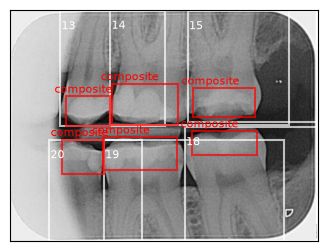

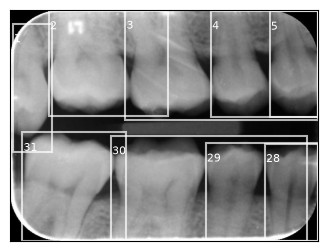

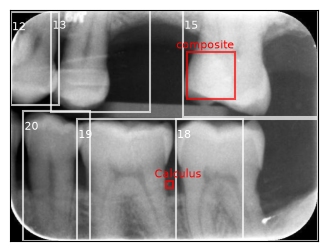

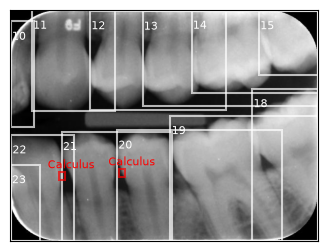

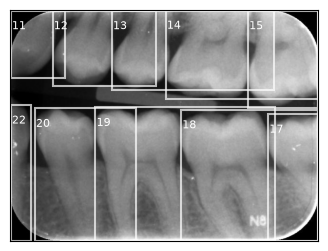

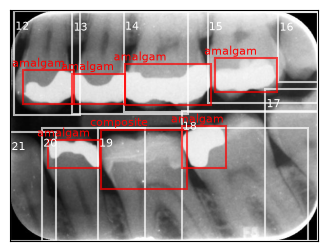

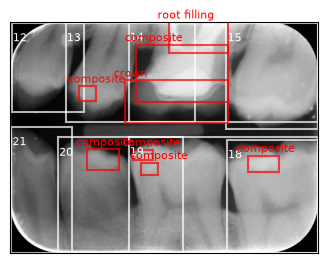

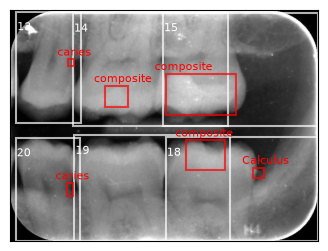

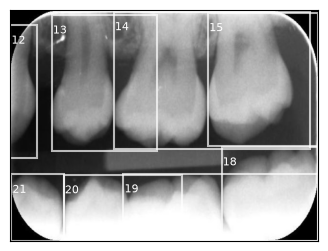

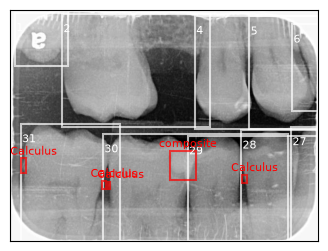

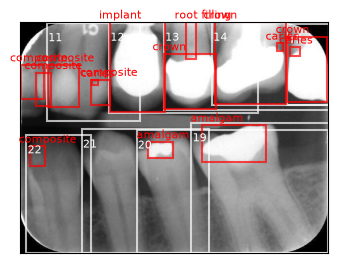

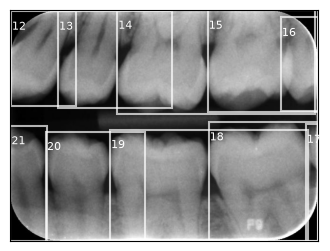

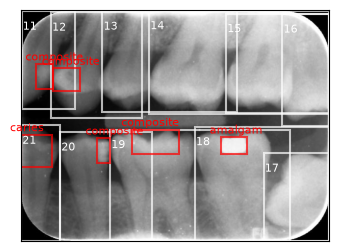

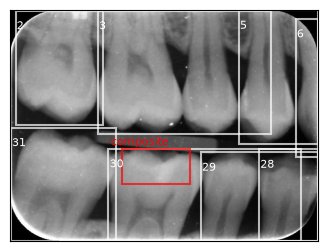

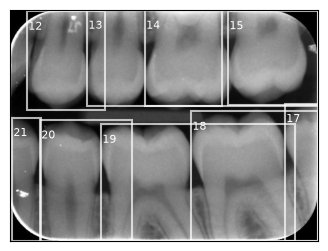

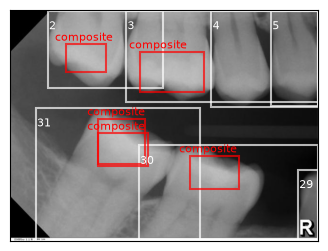

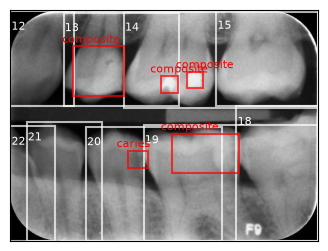

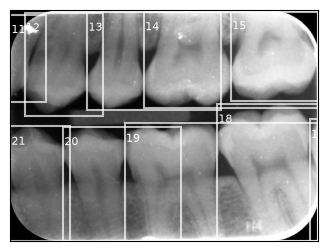

In [5]:
# Collect a number of images from the data set for demonstration
rng = np.random.default_rng(seed=123)
selected_file_list = rng.choice(file_list, size=50, replace=False)

for file in selected_file_list:

    file_name = os.path.basename(file)
    df_file = df.loc[df[file_col] == file_name].\
        reset_index(drop=True)
    
    # Load the image
    im = ImageData().load_image(file)
    xlim, ylim = (0, im.shape[1]), (0, im.shape[0])
    
    # Labels and bounding boxes for positions
    df_file_position = df_file.loc[~df_file[pos_col].isnull()]
    pos_labels = np.int64(df_file_position[pos_col].tolist())
    pos_bboxes = df_file_position[bbox_col].tolist()
    pos_bboxes = [clipxywh(list(bbox), xlim=xlim, ylim=ylim) for bbox in pos_bboxes]
    pos_bbox_dict = dict(zip(pos_labels, pos_bboxes))
    
    # Labels and bounding boxes for diseases
    # We need to convert the disease bbox from the xyxy -> xywh format
    df_file_disease = df_file.loc[(df_file[pos_col].isnull())]
    disease_labels = df_file_disease[disease_col].tolist()
    disease_bboxes = df_file_disease[bbox_col].tolist()
    disease_bboxes = [clipxywh(xyxy2xywh(list(bbox)), xlim=xlim, ylim=ylim) for bbox in disease_bboxes]
    
    # Plot the image with the bounding boxes
    fig, ax = plt.subplots(figsize = (4, 3))
    ax = plot_boxes(image=im, box_list=pos_bboxes, label_list=pos_labels, linewidth=1.5, ax=ax, color='w')
    ax = plot_boxes(image=im, box_list=disease_bboxes, label_list=disease_labels, linewidth=1.5, ax=ax, color='r', offset_xy=(-100, -120))
    
    # Before we show the image, we save it to the exampled directory
    output_file_name = f'{os.path.splitext(file_name)[0]}_boxes.png'
    output_file = os.path.join(example_dir, output_file_name)
    plt.savefig(output_file, bbox_inches='tight', transparent=True)
    plt.show()